<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Bookstore_Inventory_Movement_and_Sales_Value_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bookstore Inventory Movement and Sales Value Dataset

# About the dataset

This dataset provides a detailed look into the inventory movement and sales value within a bookstore chain. It captures monthly transactions, specifying the origin (`from`) and destination (`to`) of inventory, the stock-keeping unit (`sku`) for each book, the quantity (`qty`) moved, and associated financial metrics like `unit_cost`, `unit_price`, `extended_cost`, and `extended_retail`.

### Key Insights:

**Dataset Overview:**
*   We have a substantial record of 21,566 entries, spanning across 72 unique months, indicating a rich time-series aspect for future analysis.
*   All inventory movements originate from a single central warehouse (`YYC-WH`) and are distributed to three main destinations: `YYC-DT` (Downtown), `YYC-NW` (Northwest), and `YYC-SE` (Southeast) locations, with `YYC-DT` receiving slightly more volume.
*   The dataset covers 100 distinct book SKUs, suggesting a diverse product catalog.

**Distribution of Key Metrics:**
*   **Quantity (`qty`):** Most transactions involve smaller quantities, with an average of about 13 units. However, there are instances of larger transfers, up to 52 units, indicating varying demand or inventory needs.
*   **Costs and Prices:** The `unit_cost` ranges from approximately $6 to $17.77, while `unit_price` varies between $11.51 and $42.69. This spread implies a range of book values and corresponding profit margins.
*   **Total Values:** `extended_cost` and `extended_retail` (total cost and total retail value for a transaction) show significant variability, with maximums reaching $703.56 and $1664.91 respectively. This highlights the impact of both quantity and individual book value on overall transaction worth.

**Relationships Between Variables:**
*   As expected, there are very strong positive correlations between `qty`, `extended_cost`, and `extended_retail`. This makes intuitive sense: more units moved lead directly to higher total costs and retail values.
*   Similarly, `unit_cost` and `unit_price` are highly correlated, meaning books that cost more to acquire are generally priced higher for sale.
*   When examining categorical-numerical relationships, the `to` location seems to have some influence, with `YYC-DT` generally showing higher values for `qty`, `extended_cost`, and `extended_retail` compared to the other two branches.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d ayeshaseherr/book-store

# Unziping the downloaded file
!unzip book-store.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/ayeshaseherr/book-store
License(s): CC0-1.0
  0% 0.00/259k [00:00<?, ?B/s]
100% 259k/259k [00:00<00:00, 612MB/s]
Archive:  book-store.zip
  inflating: bookstore_inventory.csv  


In [3]:
df = pd.read_csv('bookstore_inventory.csv')
df.head(11)

,month,from,to,sku,qty,unit_cost,unit_price,extended_cost,extended_retail,dataset
0,2019-01-01,YYC-WH,YYC-DT,BK1000,19,8.09,18.92,153.71,359.48,bookstore_inventory
1,2019-01-01,YYC-WH,YYC-NW,BK1000,10,8.09,18.92,80.90,189.20,bookstore_inventory
2,2019-01-01,YYC-WH,YYC-SE,BK1000,7,8.09,18.92,56.63,132.44,bookstore_inventory
3,2019-01-01,YYC-WH,YYC-DT,BK1001,21,10.75,24.49,225.75,514.29,bookstore_inventory
4,2019-01-01,YYC-WH,YYC-NW,BK1001,13,10.75,24.49,139.75,318.37,bookstore_inventory
5,2019-01-01,YYC-WH,YYC-SE,BK1001,6,10.75,24.49,64.50,146.94,bookstore_inventory
6,2019-01-01,YYC-WH,YYC-DT,BK1002,17,15.10,31.89,256.70,542.13,bookstore_inventory
7,2019-01-01,YYC-WH,YYC-NW,BK1002,9,15.10,31.89,135.90,287.01,bookstore_inventory
8,2019-01-01,YYC-WH,YYC-SE,BK1002,7,15.10,31.89,105.70,223.23,bookstore_inventory
9,2019-01-01,YYC-WH,YYC-DT,BK1003,21,14.35,28.58,301.35,600.18,bookstore_inventory


In [4]:
df.tail(11)

,month,from,to,sku,qty,unit_cost,unit_price,extended_cost,extended_retail,dataset
21555,2024-12-01,YYC-WH,YYC-NW,BK1096,13,6.30,15.47,81.90,201.11,bookstore_inventory
21556,2024-12-01,YYC-WH,YYC-SE,BK1096,15,6.30,15.47,94.50,232.05,bookstore_inventory
21557,2024-12-01,YYC-WH,YYC-DT,BK1097,29,6.27,11.51,181.83,333.79,bookstore_inventory
21558,2024-12-01,YYC-WH,YYC-NW,BK1097,17,6.27,11.51,106.59,195.67,bookstore_inventory
21559,2024-12-01,YYC-WH,YYC-SE,BK1097,22,6.27,11.51,137.94,253.22,bookstore_inventory
21560,2024-12-01,YYC-WH,YYC-DT,BK1098,14,9.88,21.53,138.32,301.42,bookstore_inventory
21561,2024-12-01,YYC-WH,YYC-NW,BK1098,16,9.88,21.53,158.08,344.48,bookstore_inventory
21562,2024-12-01,YYC-WH,YYC-SE,BK1098,10,9.88,21.53,98.80,215.30,bookstore_inventory
21563,2024-12-01,YYC-WH,YYC-DT,BK1099,22,11.86,27.23,260.92,599.06,bookstore_inventory
21564,2024-12-01,YYC-WH,YYC-NW,BK1099,20,11.86,27.23,237.20,544.60,bookstore_inventory


In [5]:
df.shape

(21566, 10)

In [6]:
df.columns

Index(['month', 'from', 'to', 'sku', 'qty', 'unit_cost', 'unit_price',
       'extended_cost', 'extended_retail', 'dataset'],
      dtype='object')

In [7]:
df.dtypes

,0
month,object
from,object
to,object
sku,object
qty,int64
unit_cost,float64
unit_price,float64
extended_cost,float64
extended_retail,float64
dataset,object


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21566 entries, 0 to 21565
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   month            21566 non-null  object 
 1   from             21566 non-null  object 
 2   to               21566 non-null  object 
 3   sku              21566 non-null  object 
 4   qty              21566 non-null  int64  
 5   unit_cost        21566 non-null  float64
 6   unit_price       21566 non-null  float64
 7   extended_cost    21566 non-null  float64
 8   extended_retail  21566 non-null  float64
 9   dataset          21566 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 1.6+ MB


In [10]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
month,21566,72,2019-01-01,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN
from,21566,1,YYC-WH,21566,NaN,NaN,NaN,NaN,NaN,NaN,NaN
to,21566,3,YYC-DT,7198,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sku,21566,100,BK1000,216,NaN,NaN,NaN,NaN,NaN,NaN,NaN
qty,21566.0,NaN,NaN,NaN,13.60702,6.483232,1.0,9.0,13.0,17.0,52.0
unit_cost,21566.0,NaN,NaN,NaN,12.380085,3.528916,6.08,9.12,13.11,15.36,17.77
unit_price,21566.0,NaN,NaN,NaN,26.32348,7.857572,11.51,18.92,27.05,31.93,42.69
extended_cost,21566.0,NaN,NaN,NaN,168.395885,95.771328,6.27,98.1,150.1,219.1675,703.56
extended_retail,21566.0,NaN,NaN,NaN,358.156324,206.848009,11.51,205.38,320.4,467.21,1664.91
dataset,21566,1,bookstore_inventory,21566,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df.isnull().sum()

,0
month,0
from,0
to,0
sku,0
qty,0
unit_cost,0
unit_price,0
extended_cost,0
extended_retail,0
dataset,0


In [12]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

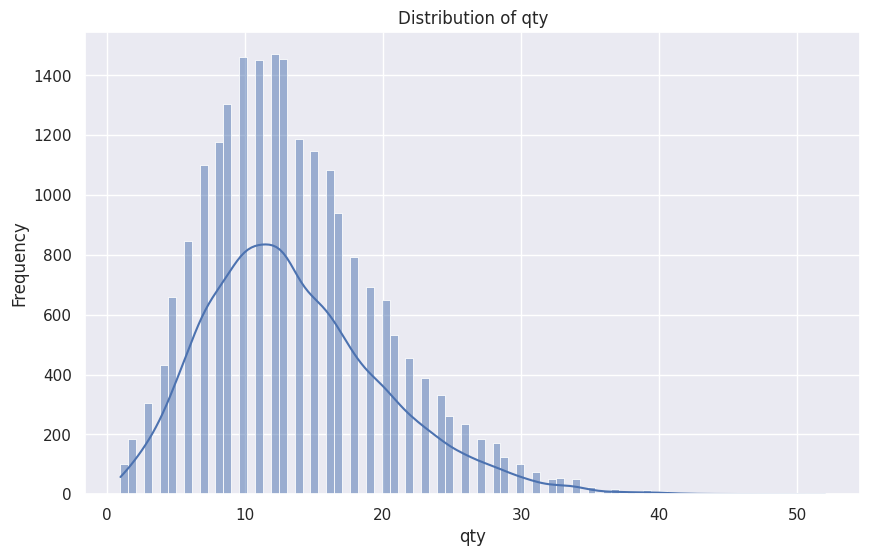

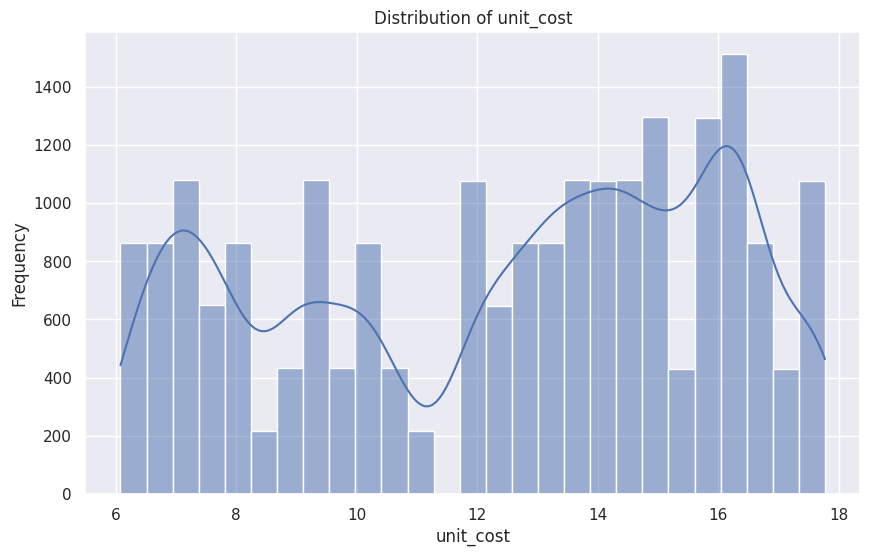

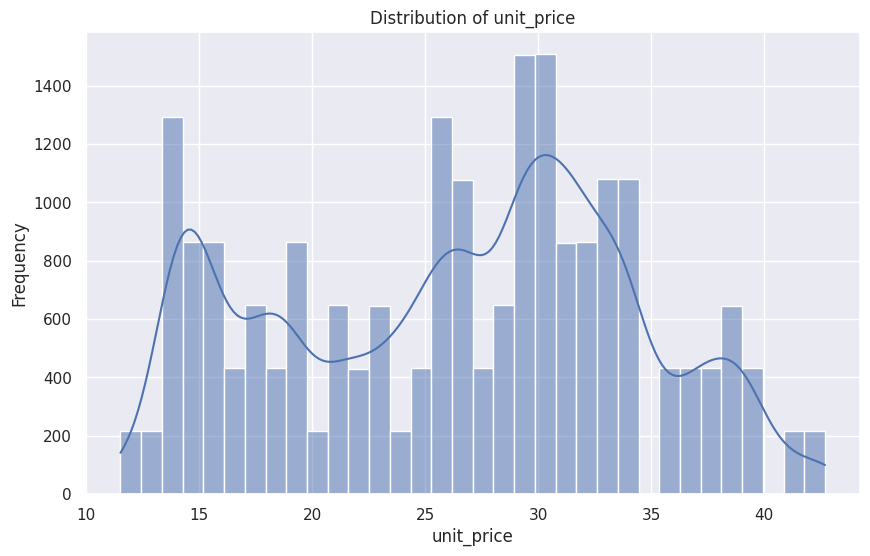

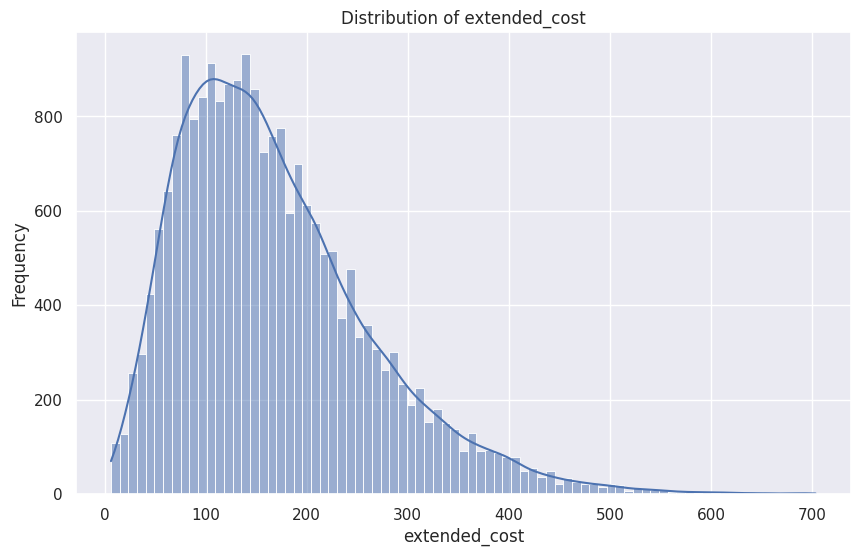

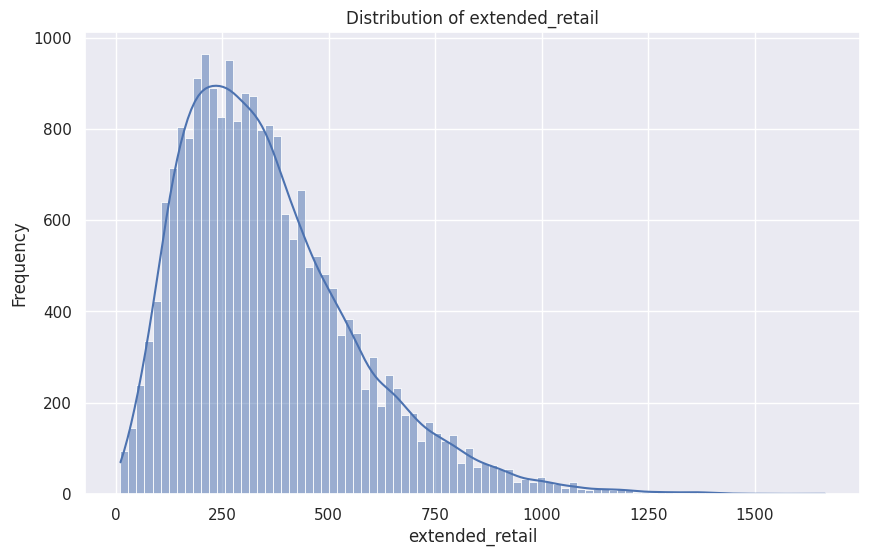

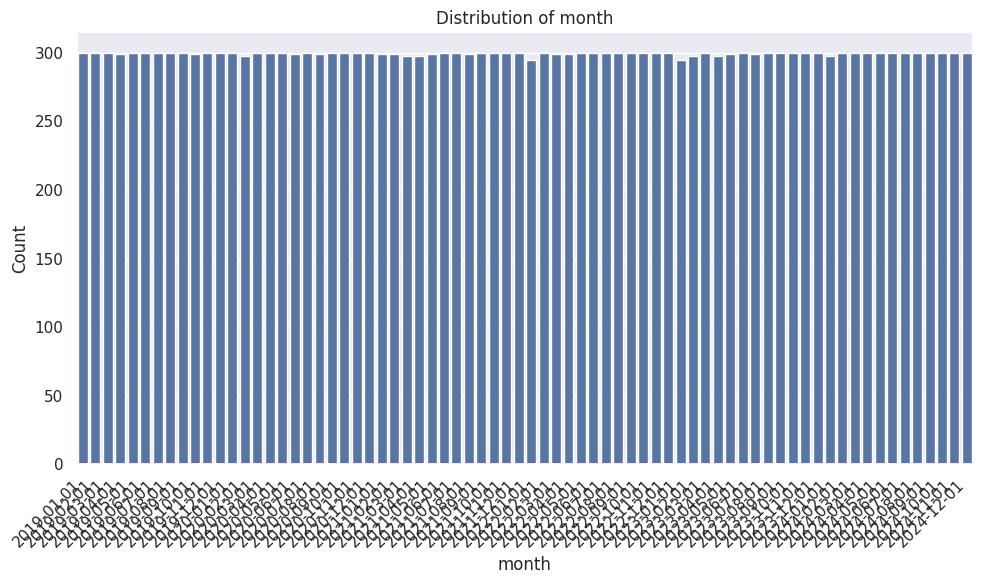

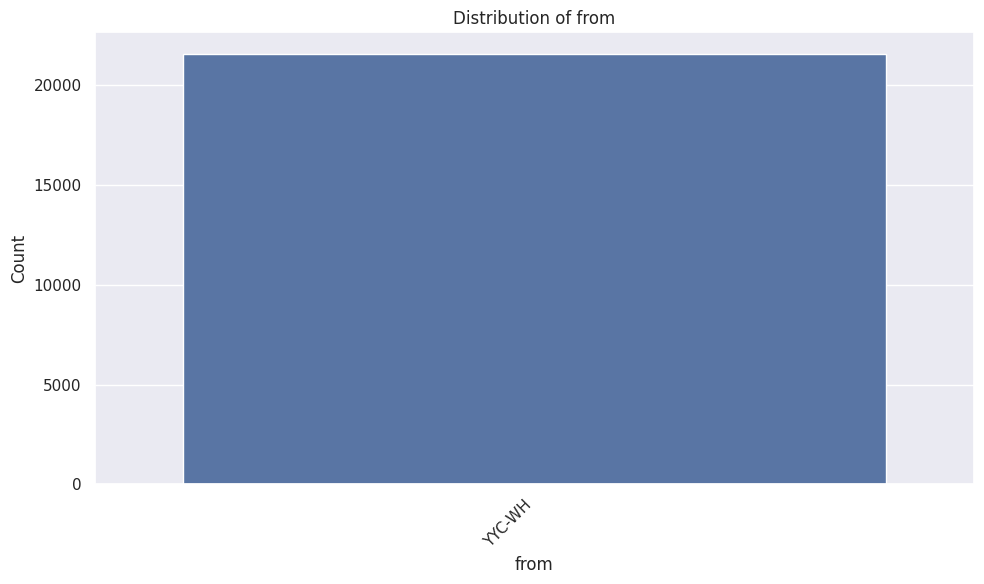

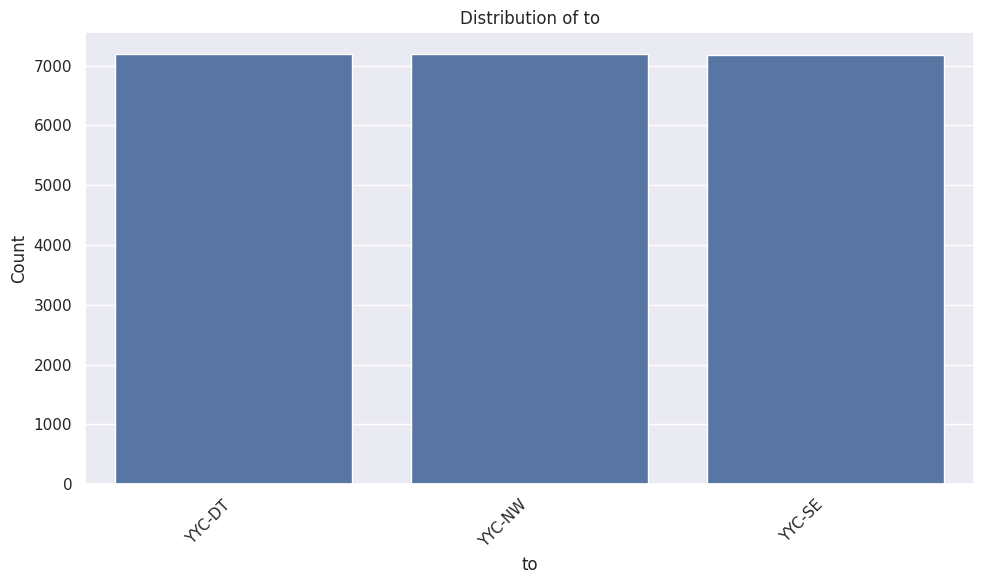

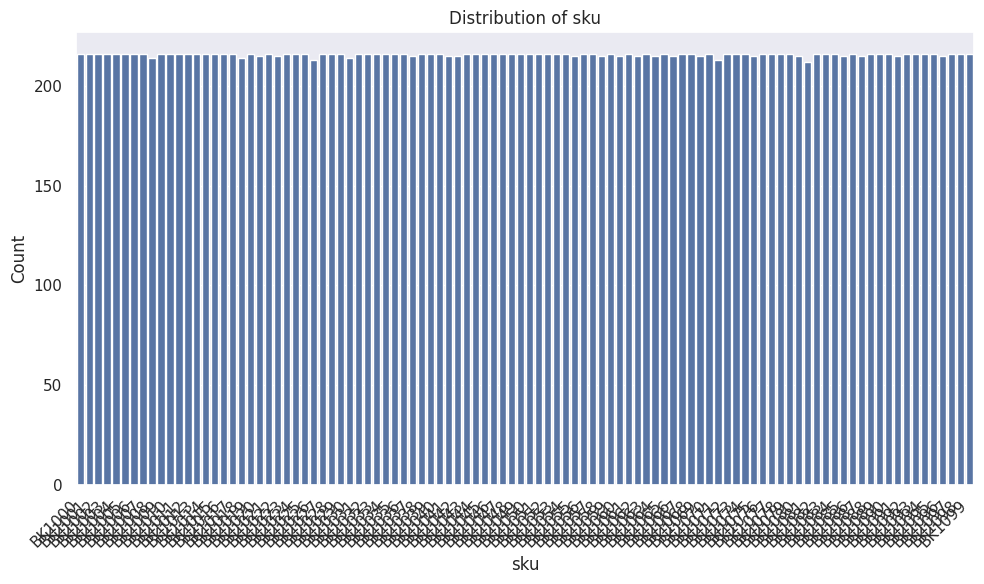

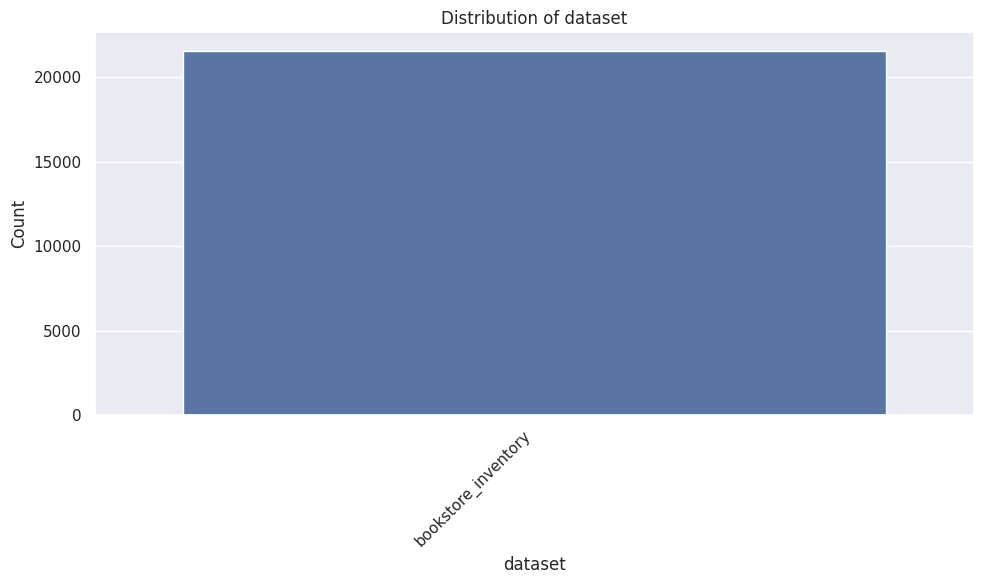

Value counts for month:
month
2019-01-01    300
2019-02-01    300
2019-03-01    300
2019-05-01    300
2019-07-01    300
             ... 
2020-02-01    298
2024-01-01    298
2023-04-01    298
2022-01-01    295
2023-01-01    295
Name: count, Length: 72, dtype: int64

Value counts for from:
from
YYC-WH    21566
Name: count, dtype: int64

Value counts for to:
to
YYC-DT    7198
YYC-NW    7190
YYC-SE    7178
Name: count, dtype: int64

Value counts for sku:
sku
BK1000    216
BK1001    216
BK1002    216
BK1003    216
BK1004    216
         ... 
BK1018    214
BK1030    214
BK1026    213
BK1071    213
BK1081    212
Name: count, Length: 100, dtype: int64

Value counts for dataset:
dataset
bookstore_inventory    21566
Name: count, dtype: int64



In [15]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

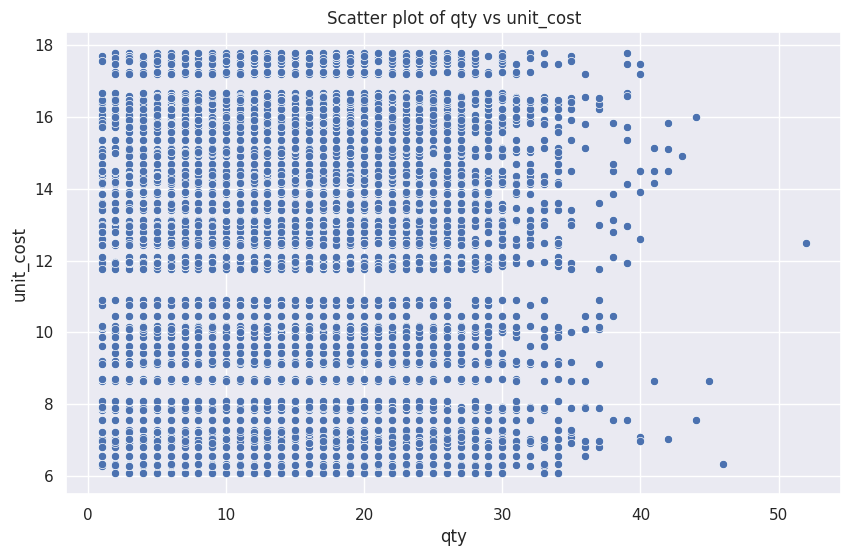

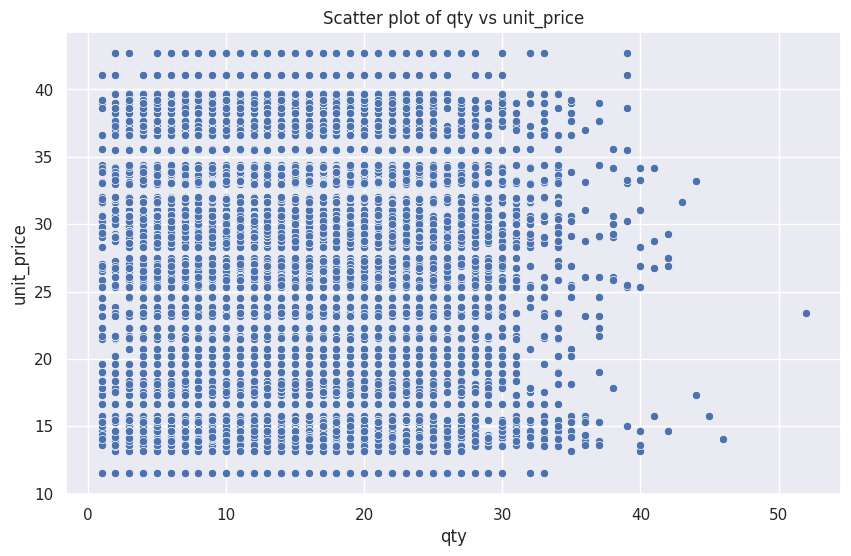

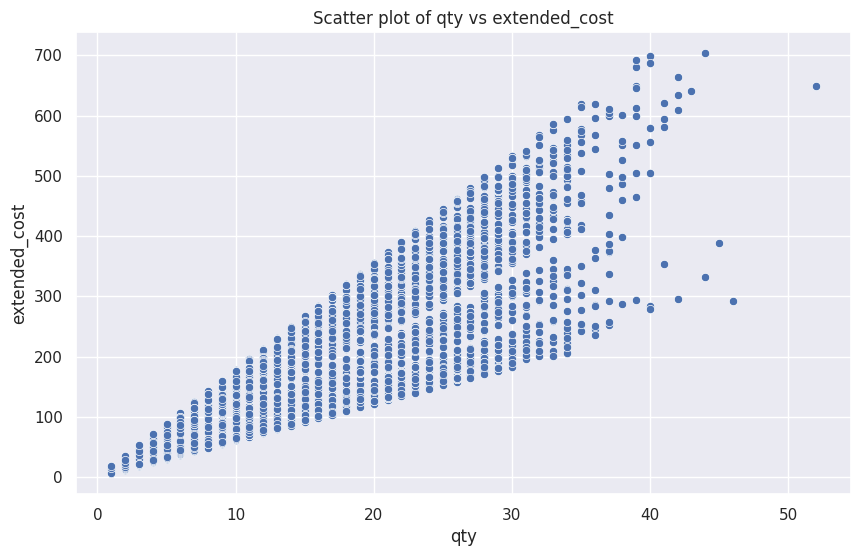

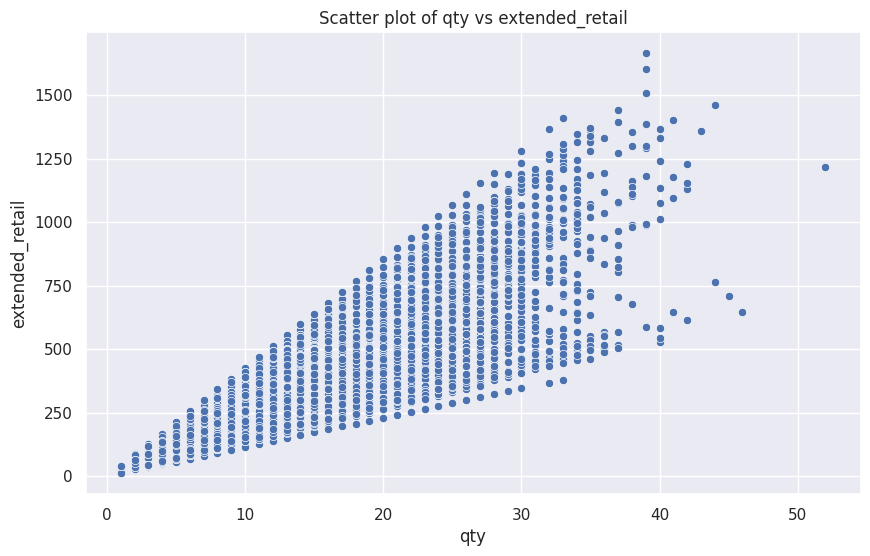

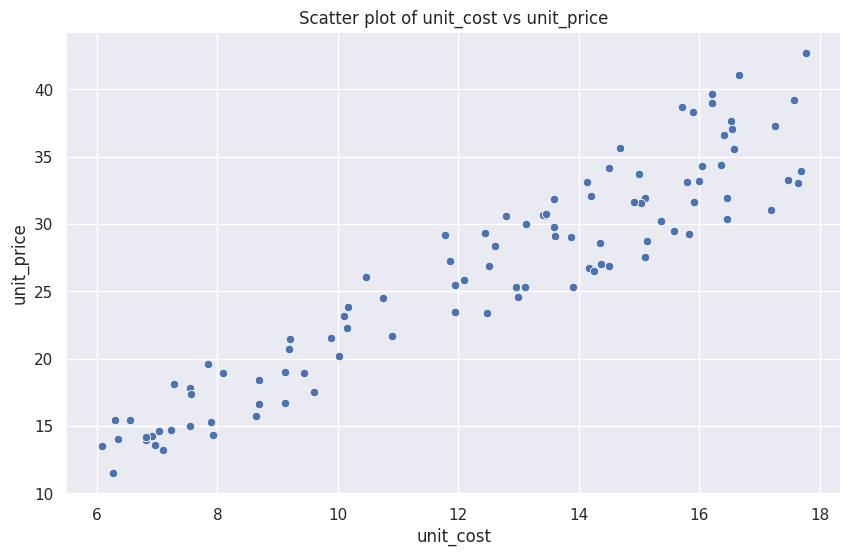

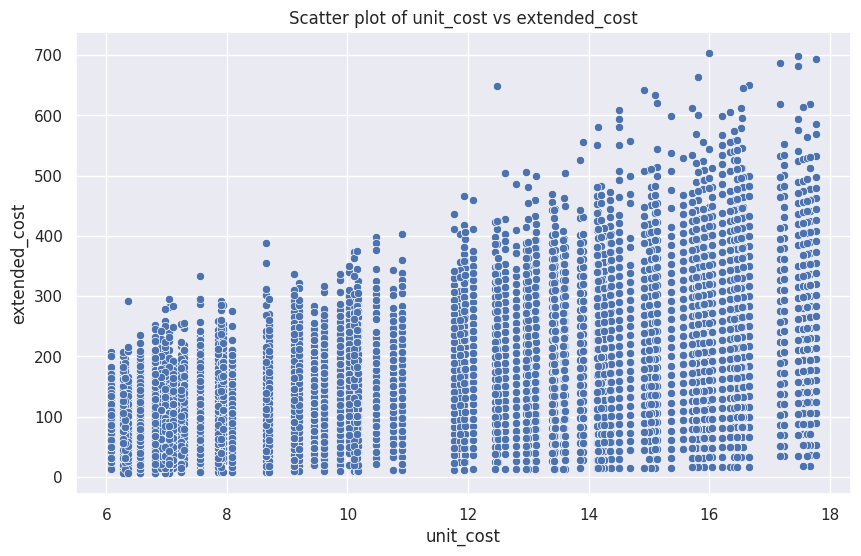

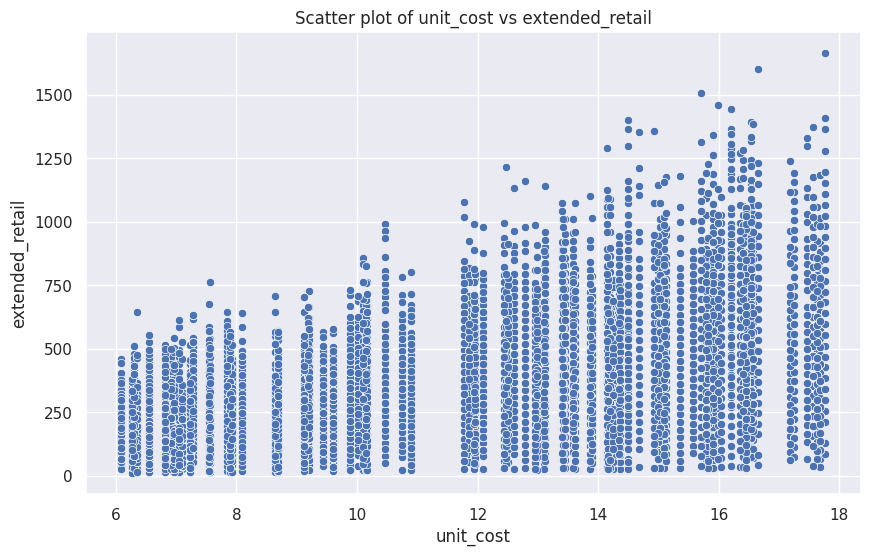

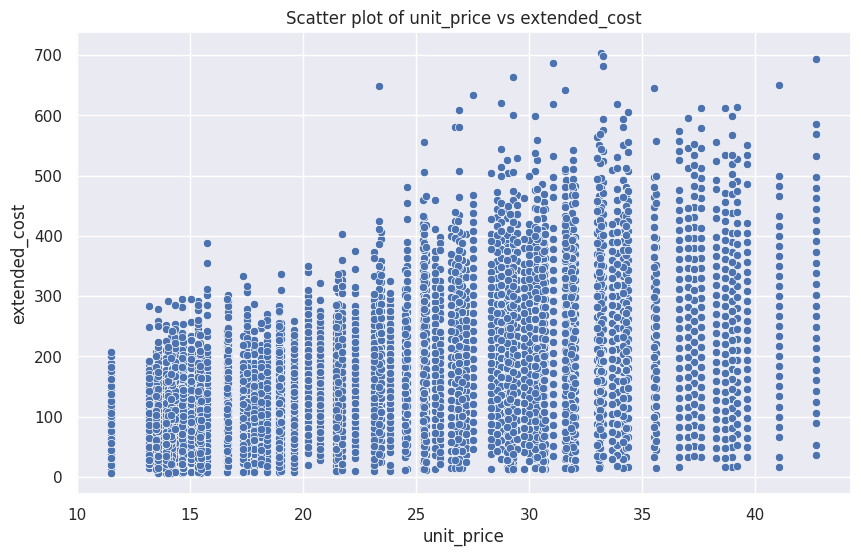

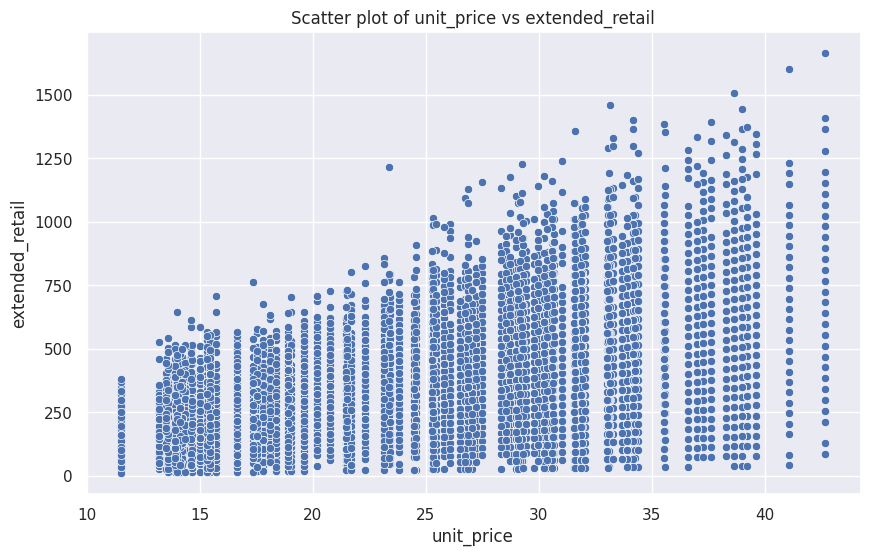

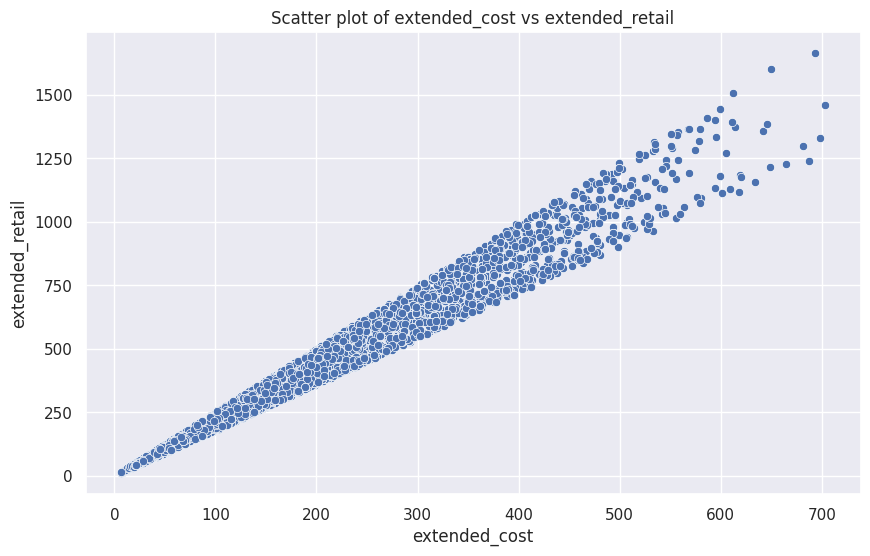

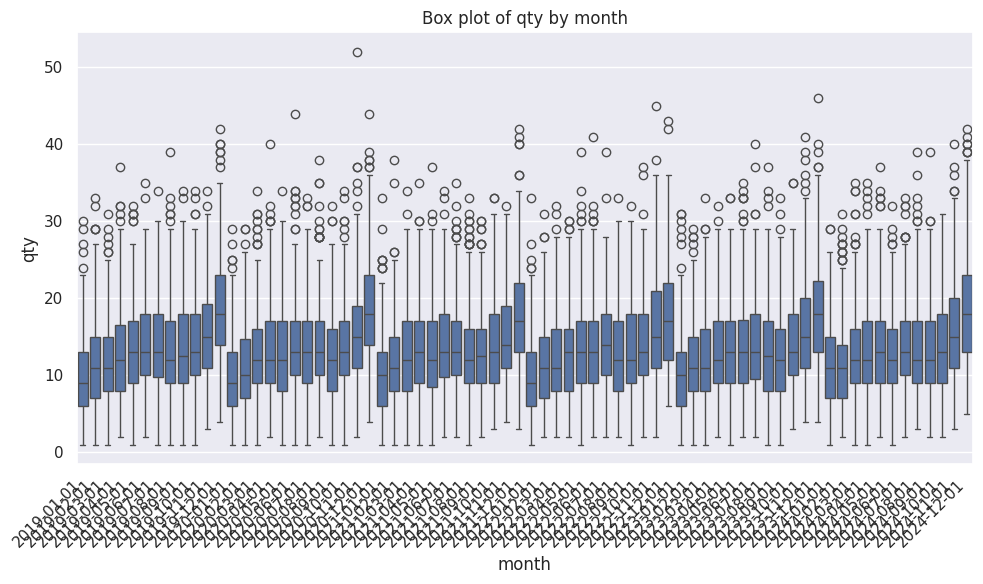

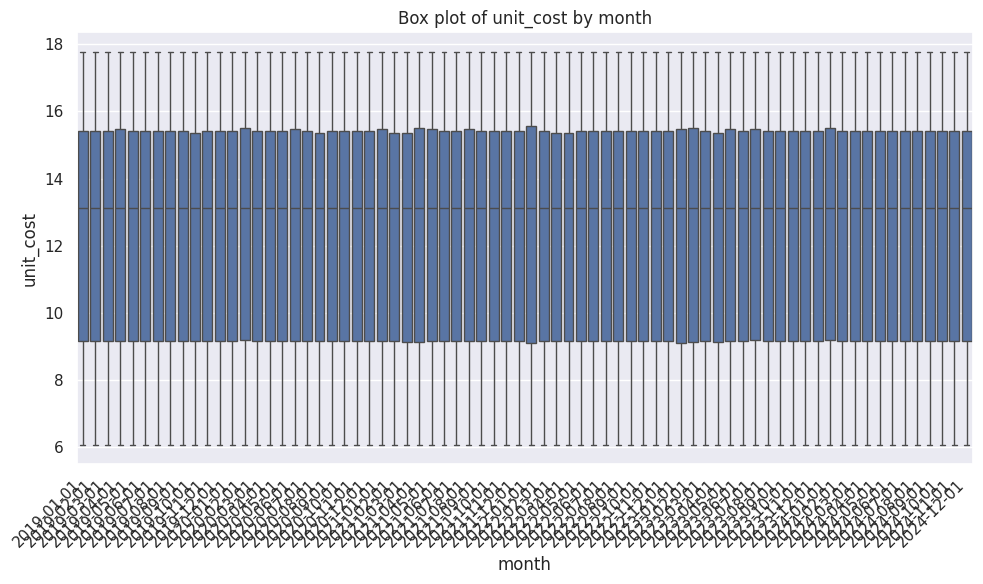

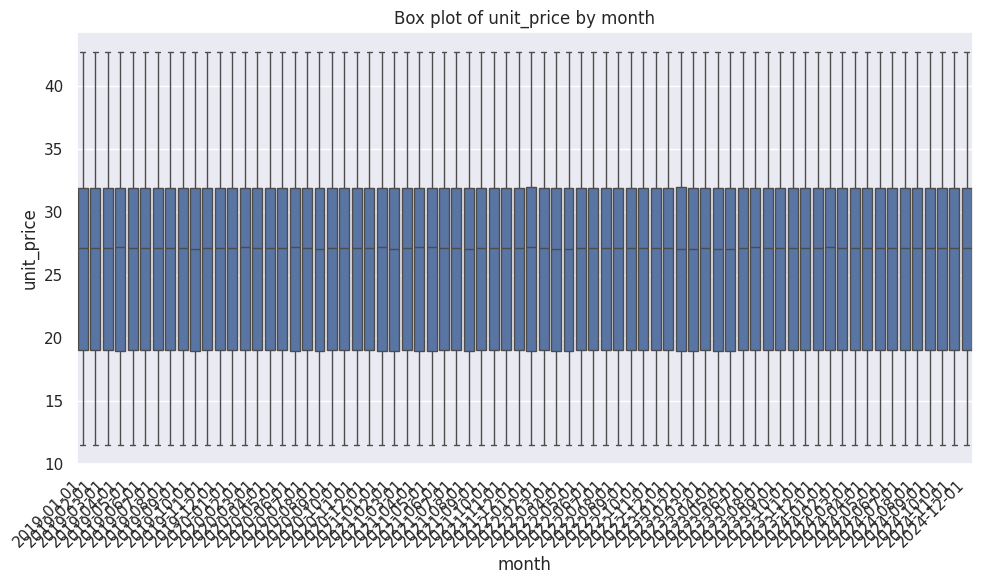

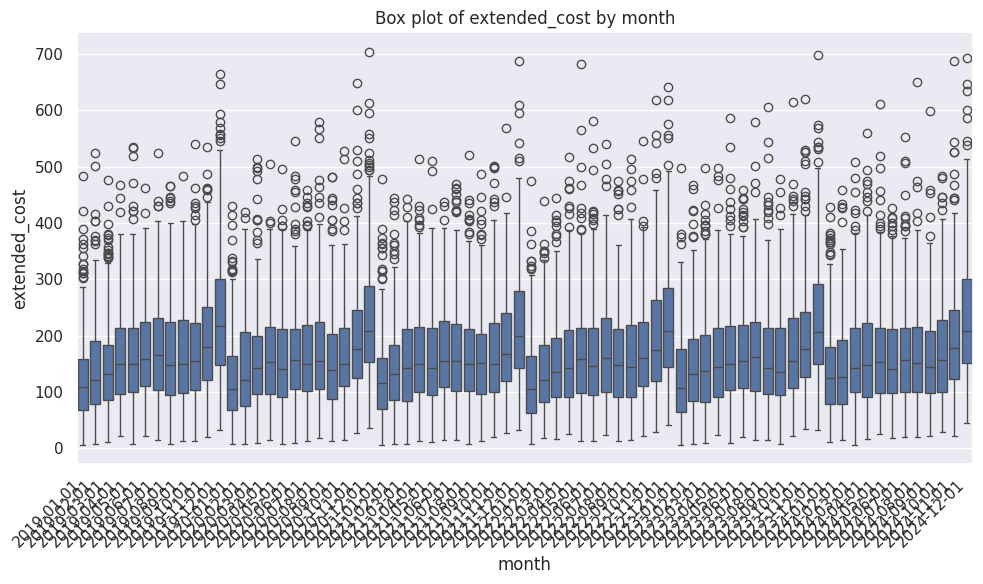

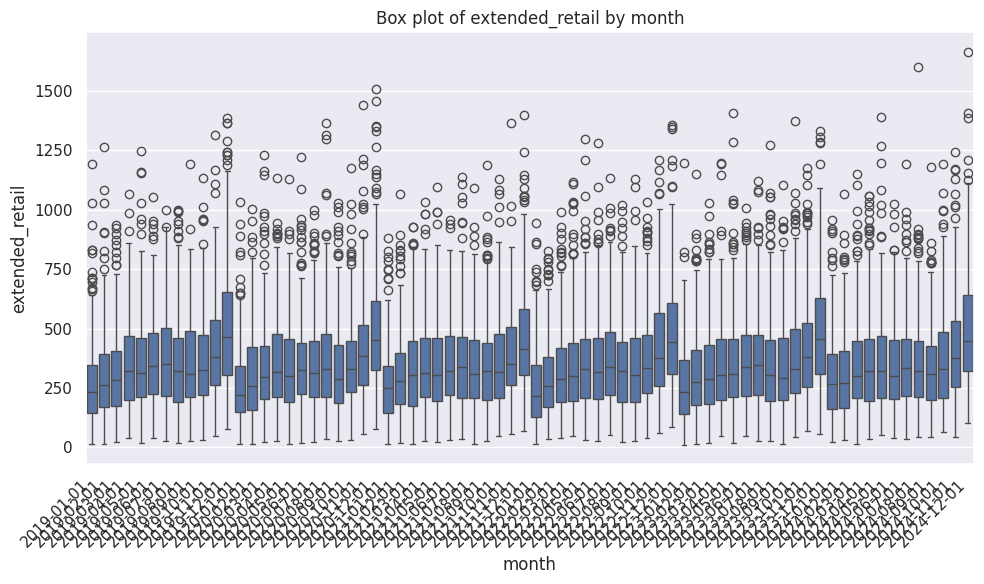

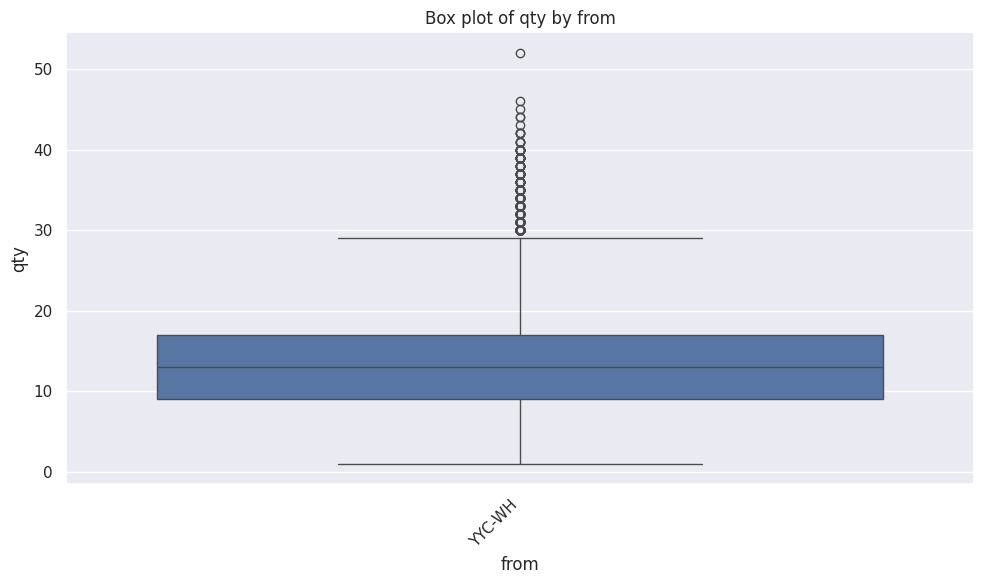

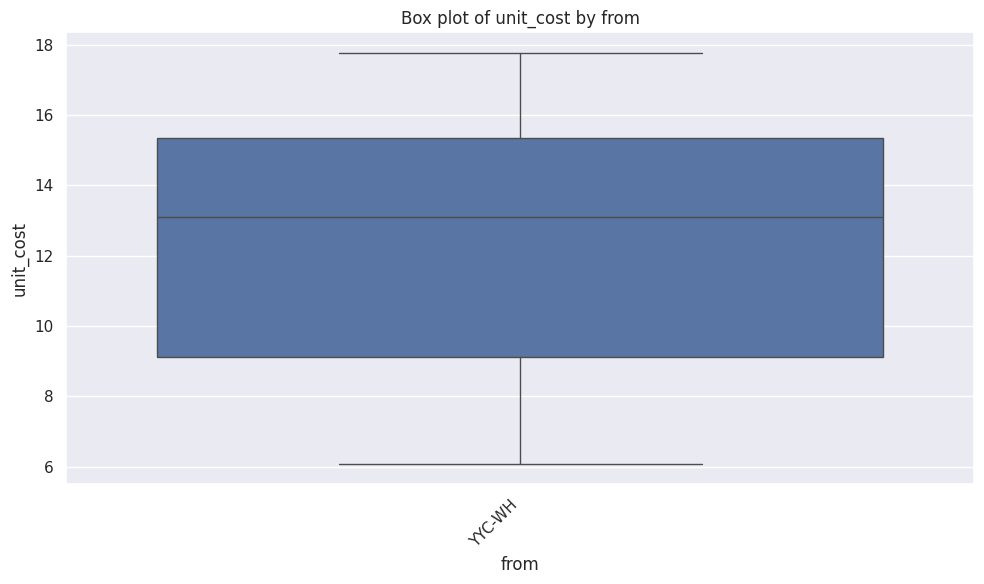

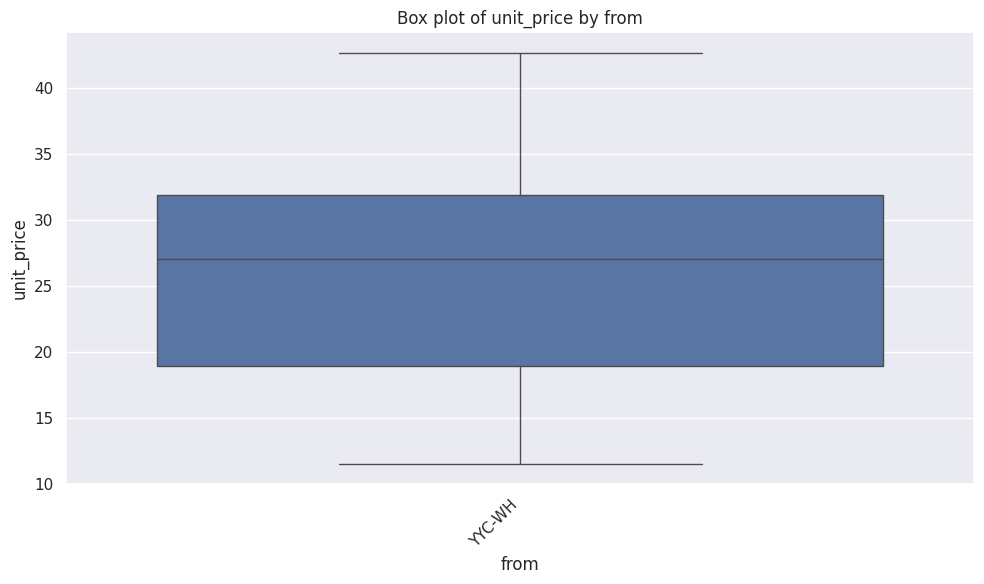

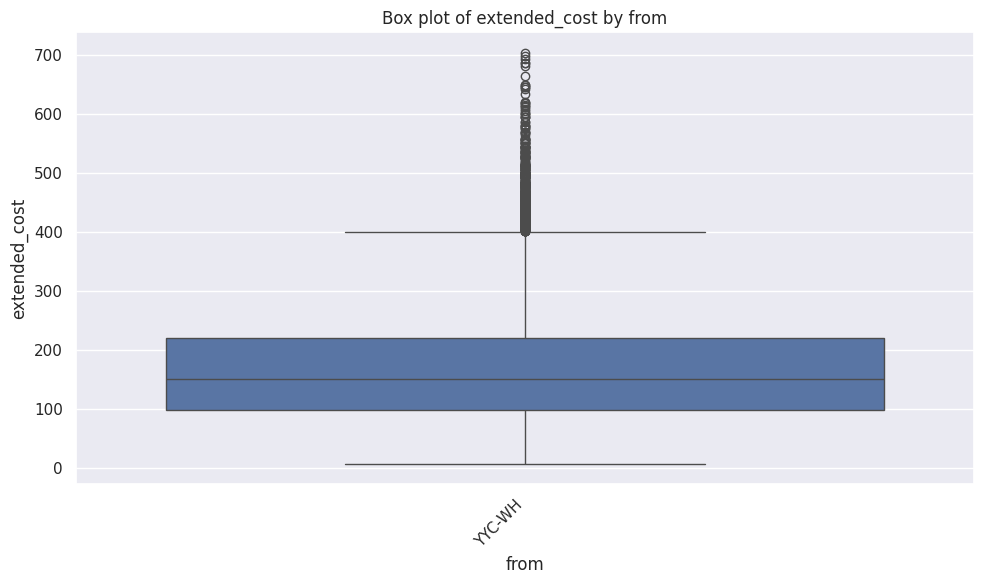

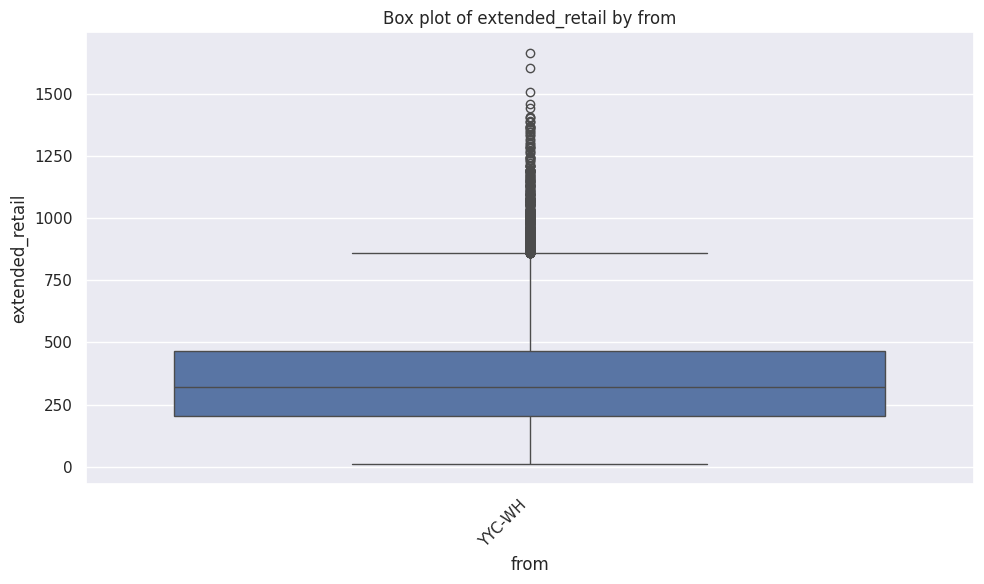

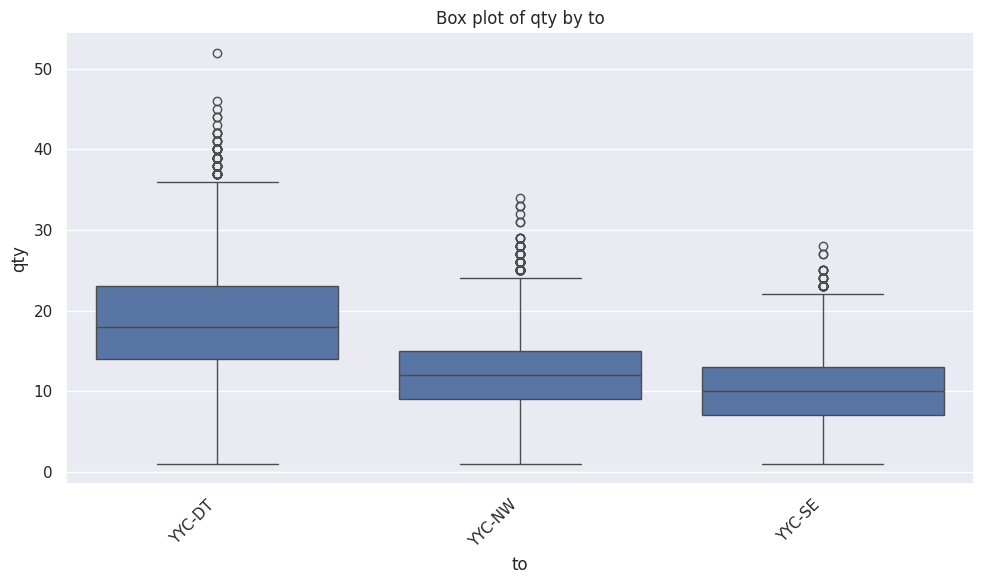

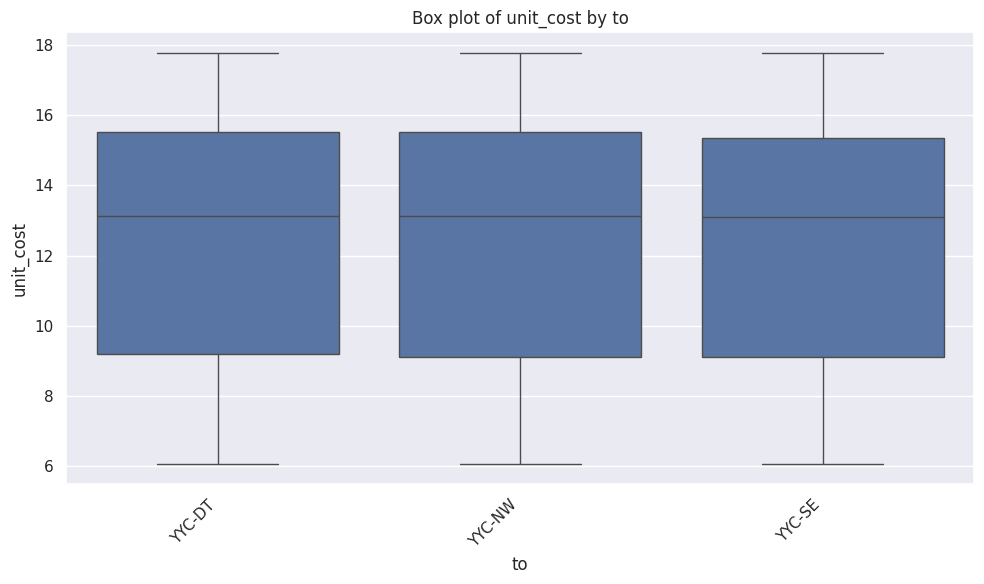

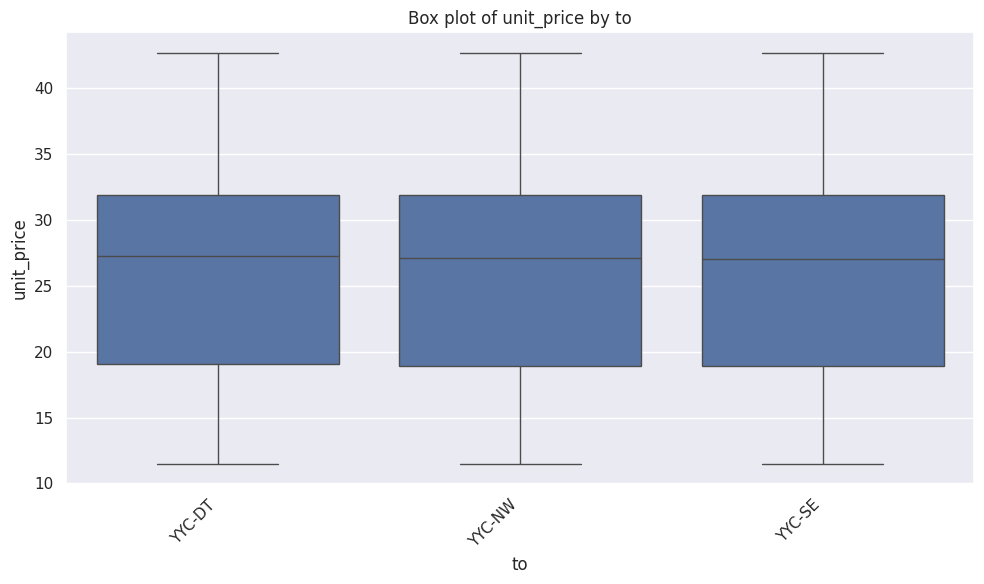

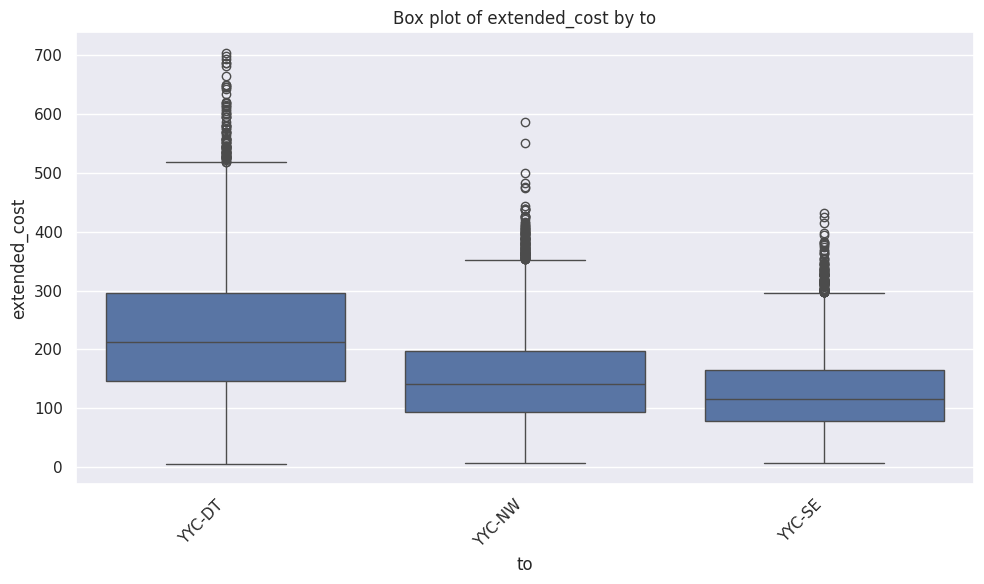

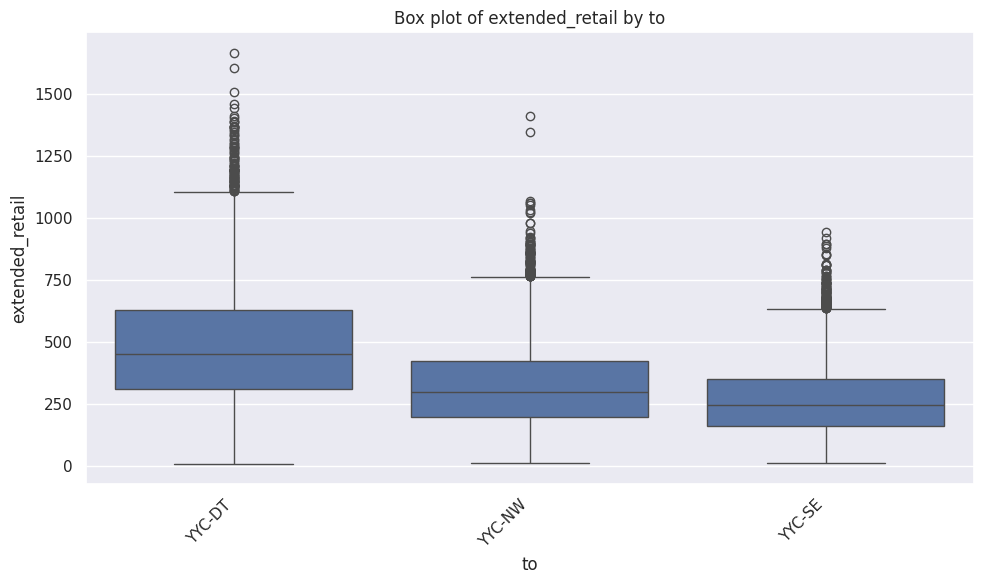

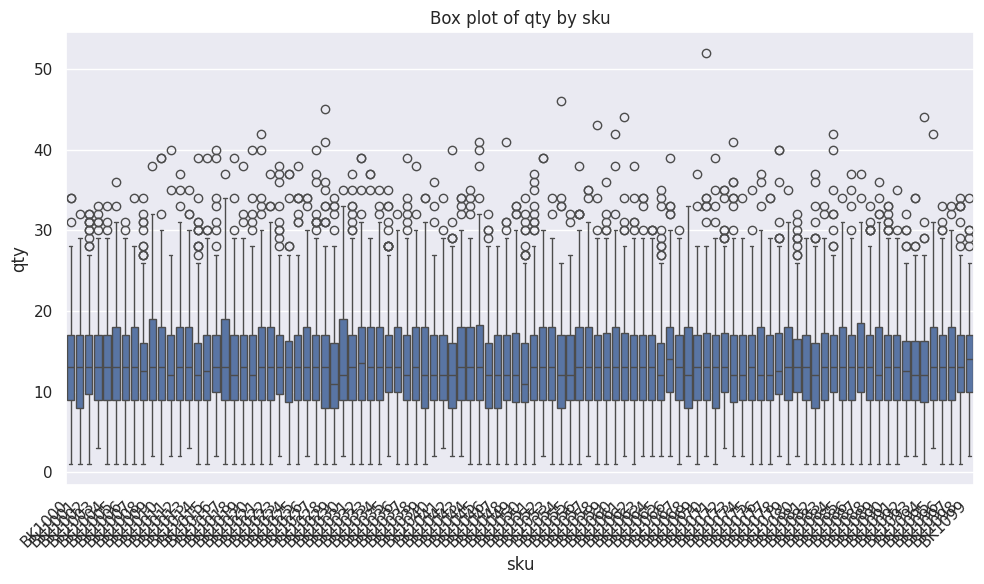

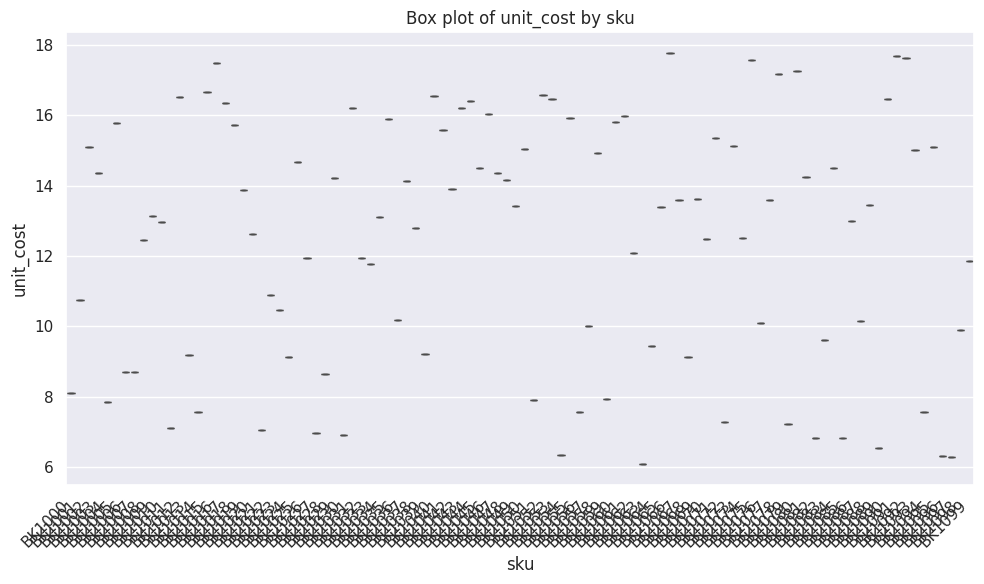

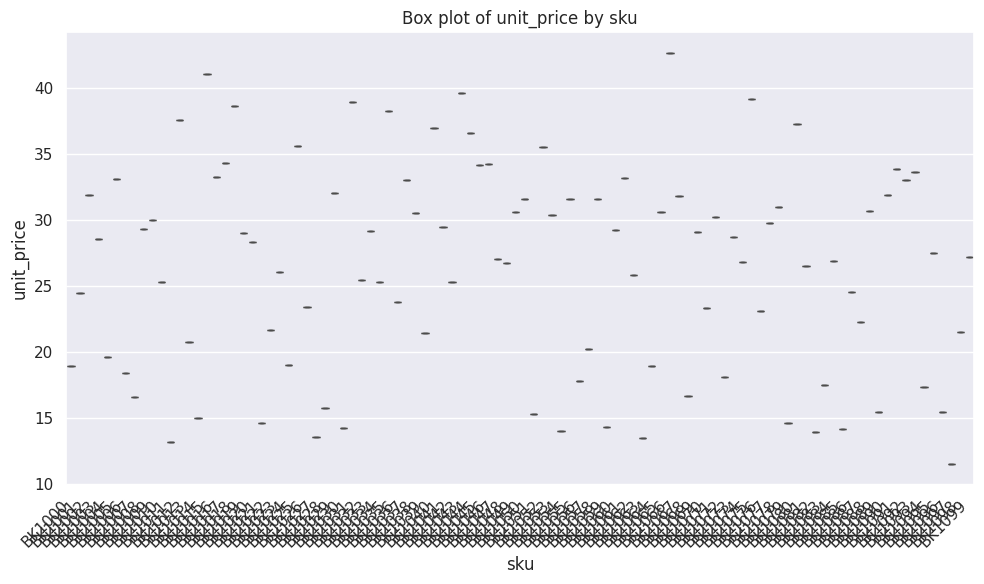

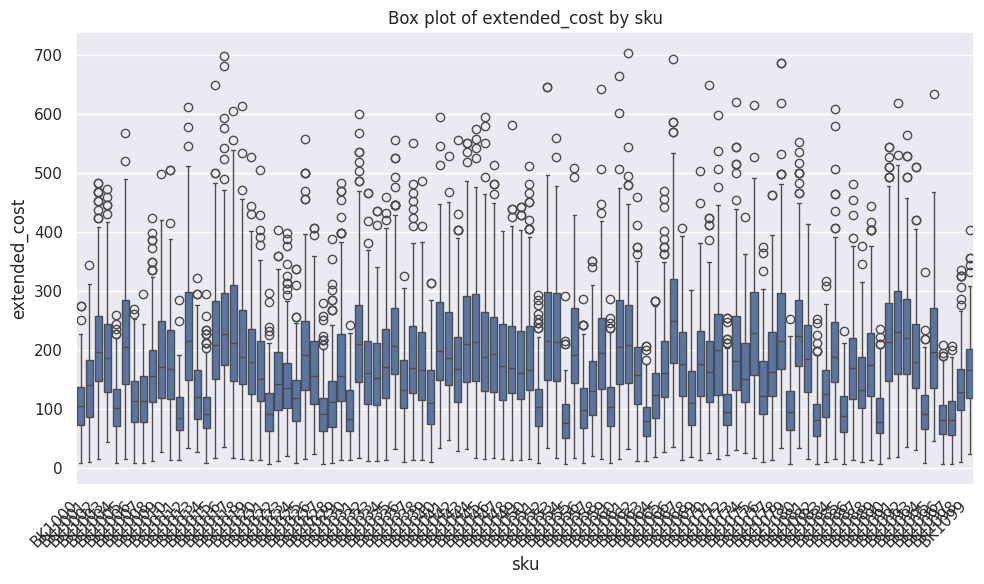

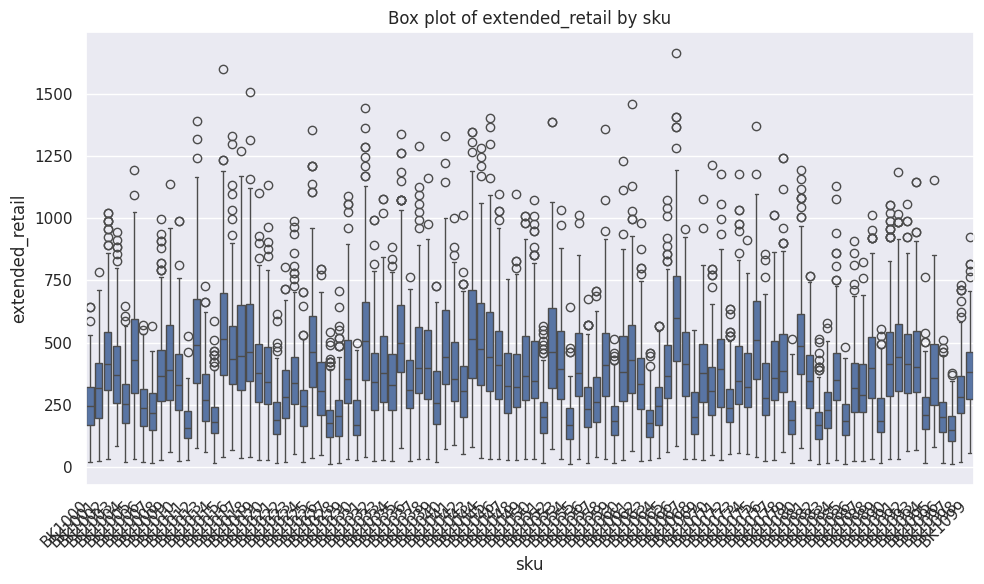

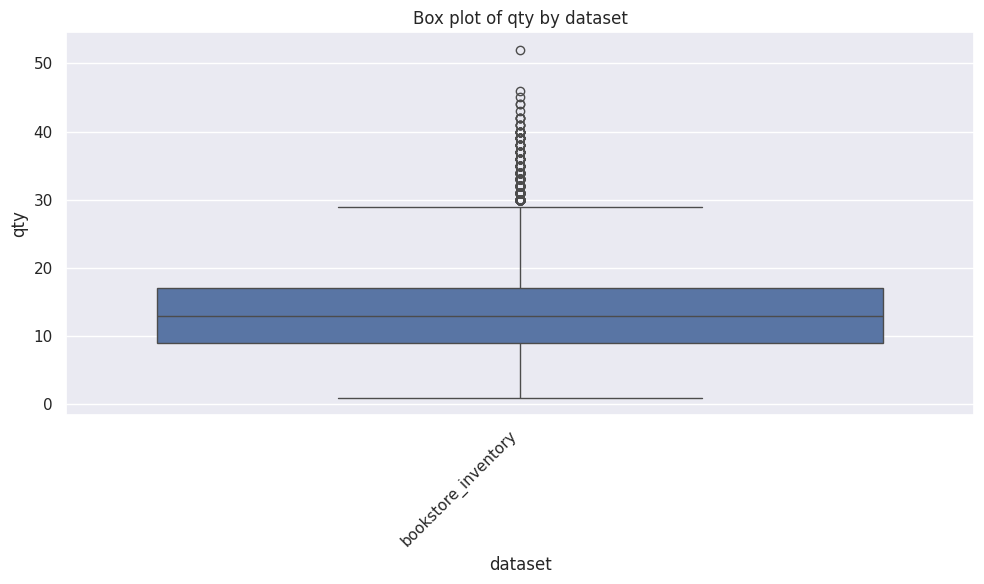

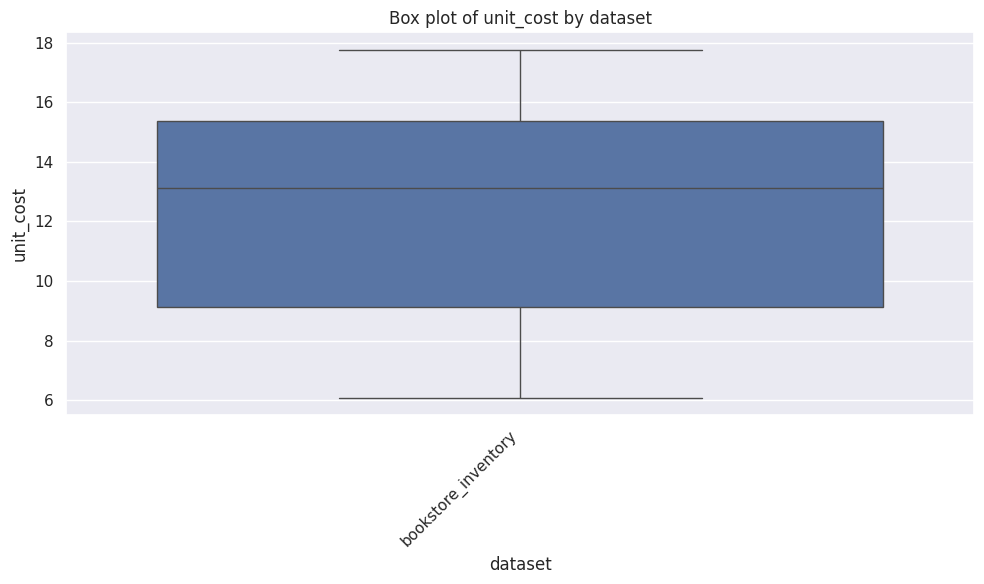

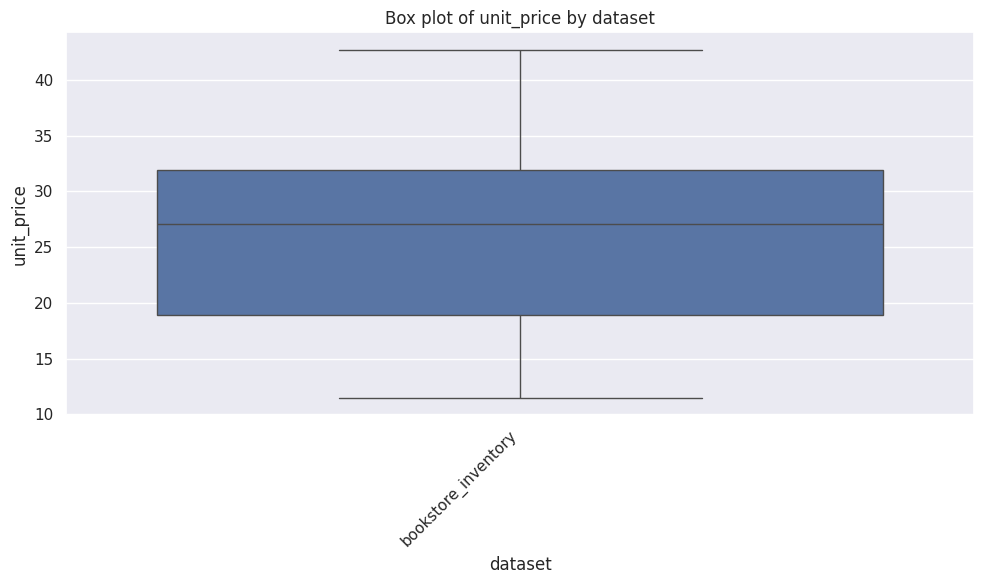

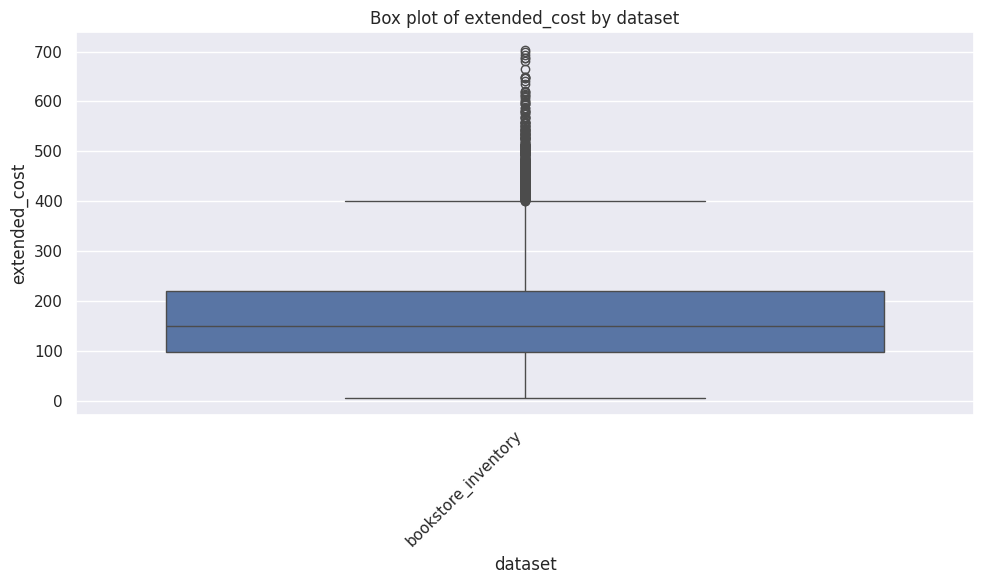

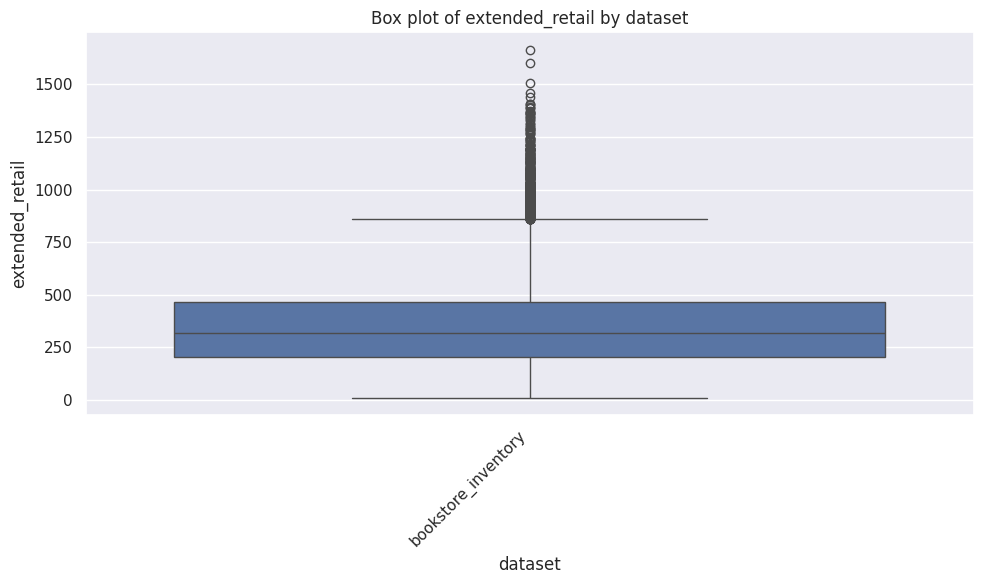

In [16]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

### 1. Time Series Analysis: Monthly Trends

First, let's ensure our `month` column is in datetime format, then aggregate the data to visualize the total quantity moved and total extended retail value each month. This will help us identify any trends, seasonality, or anomalies over the observed period.

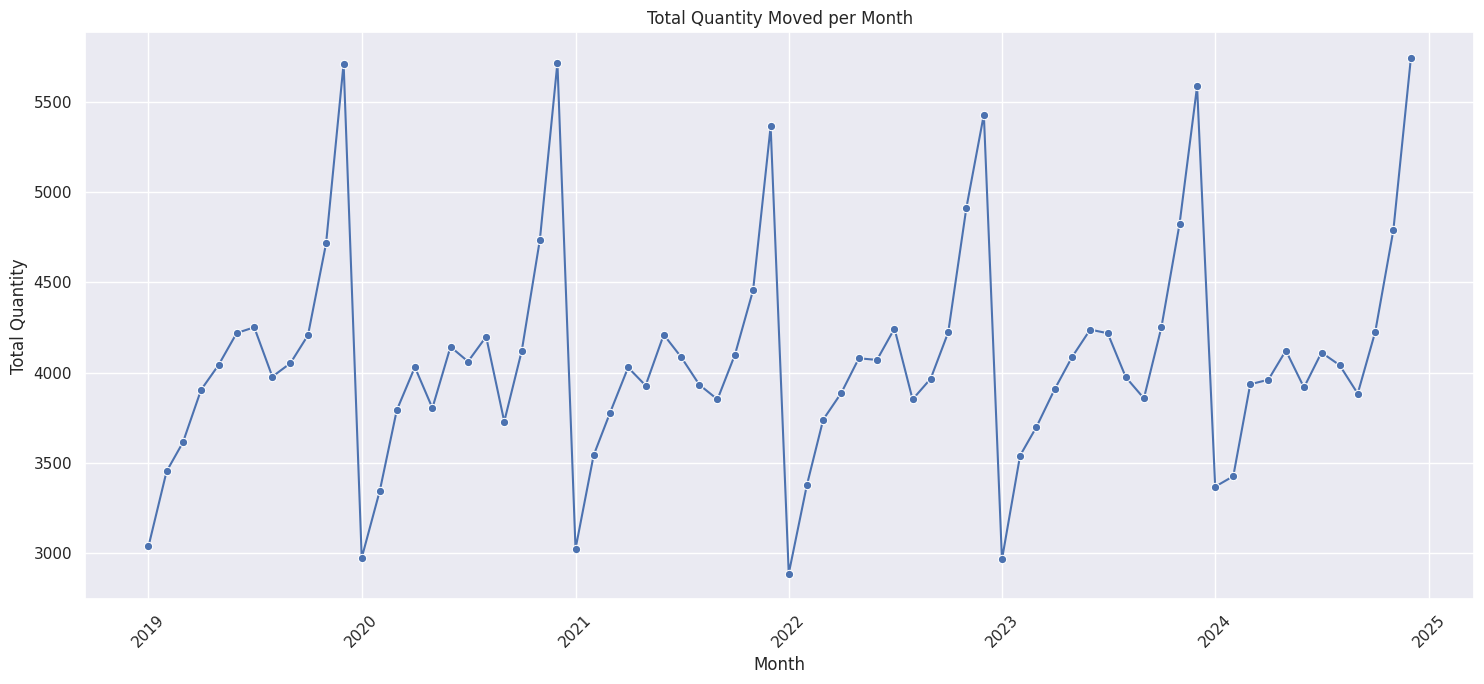

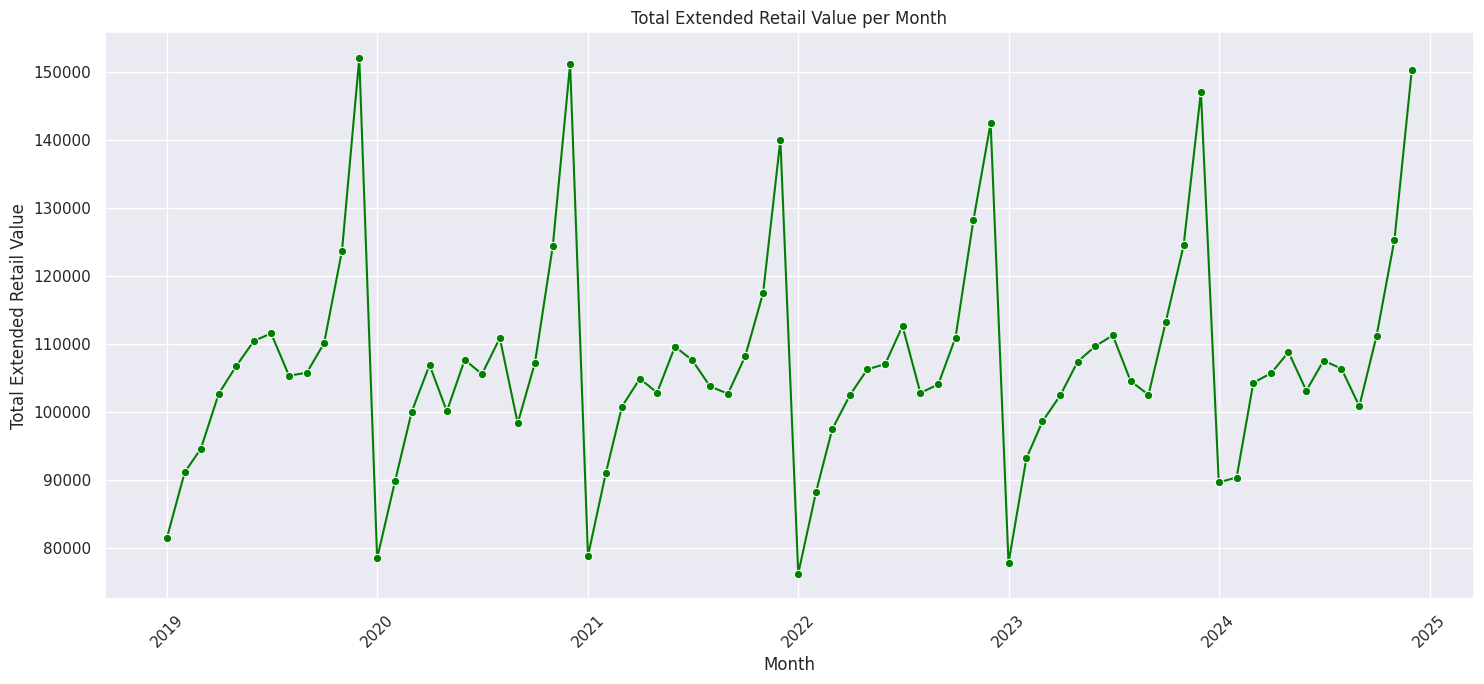

In [19]:
df['month'] = pd.to_datetime(df['month'])

monthly_summary = df.groupby('month').agg(
    total_qty=('qty', 'sum'),
    total_extended_retail=('extended_retail', 'sum')
).reset_index()

plt.figure(figsize=(15, 7))
sns.lineplot(data=monthly_summary, x='month', y='total_qty', marker='o')
plt.title('Total Quantity Moved per Month')
plt.xlabel('Month')
plt.ylabel('Total Quantity')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 7))
sns.lineplot(data=monthly_summary, x='month', y='total_extended_retail', marker='o', color='green')
plt.title('Total Extended Retail Value per Month')
plt.xlabel('Month')
plt.ylabel('Total Extended Retail Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2. Location-based Comparison: Extended Retail by Destination

Next, let's compare the total extended retail value across the different destination branches (`to` column). This can highlight which locations generate the most revenue.

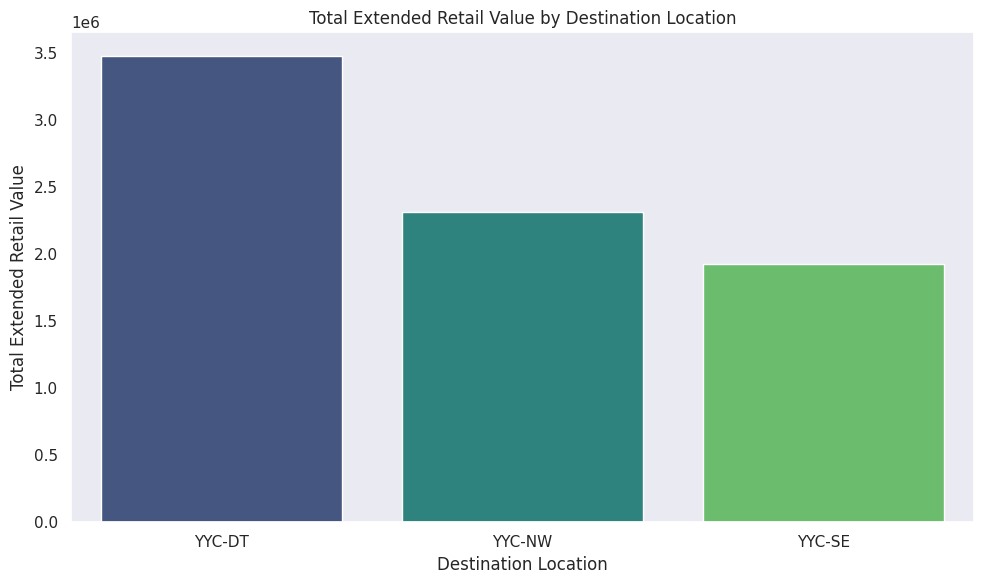

In [20]:
location_retail = df.groupby('to')['extended_retail'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=location_retail, x='to', y='extended_retail', palette='viridis')
plt.title('Total Extended Retail Value by Destination Location')
plt.xlabel('Destination Location')
plt.ylabel('Total Extended Retail Value')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

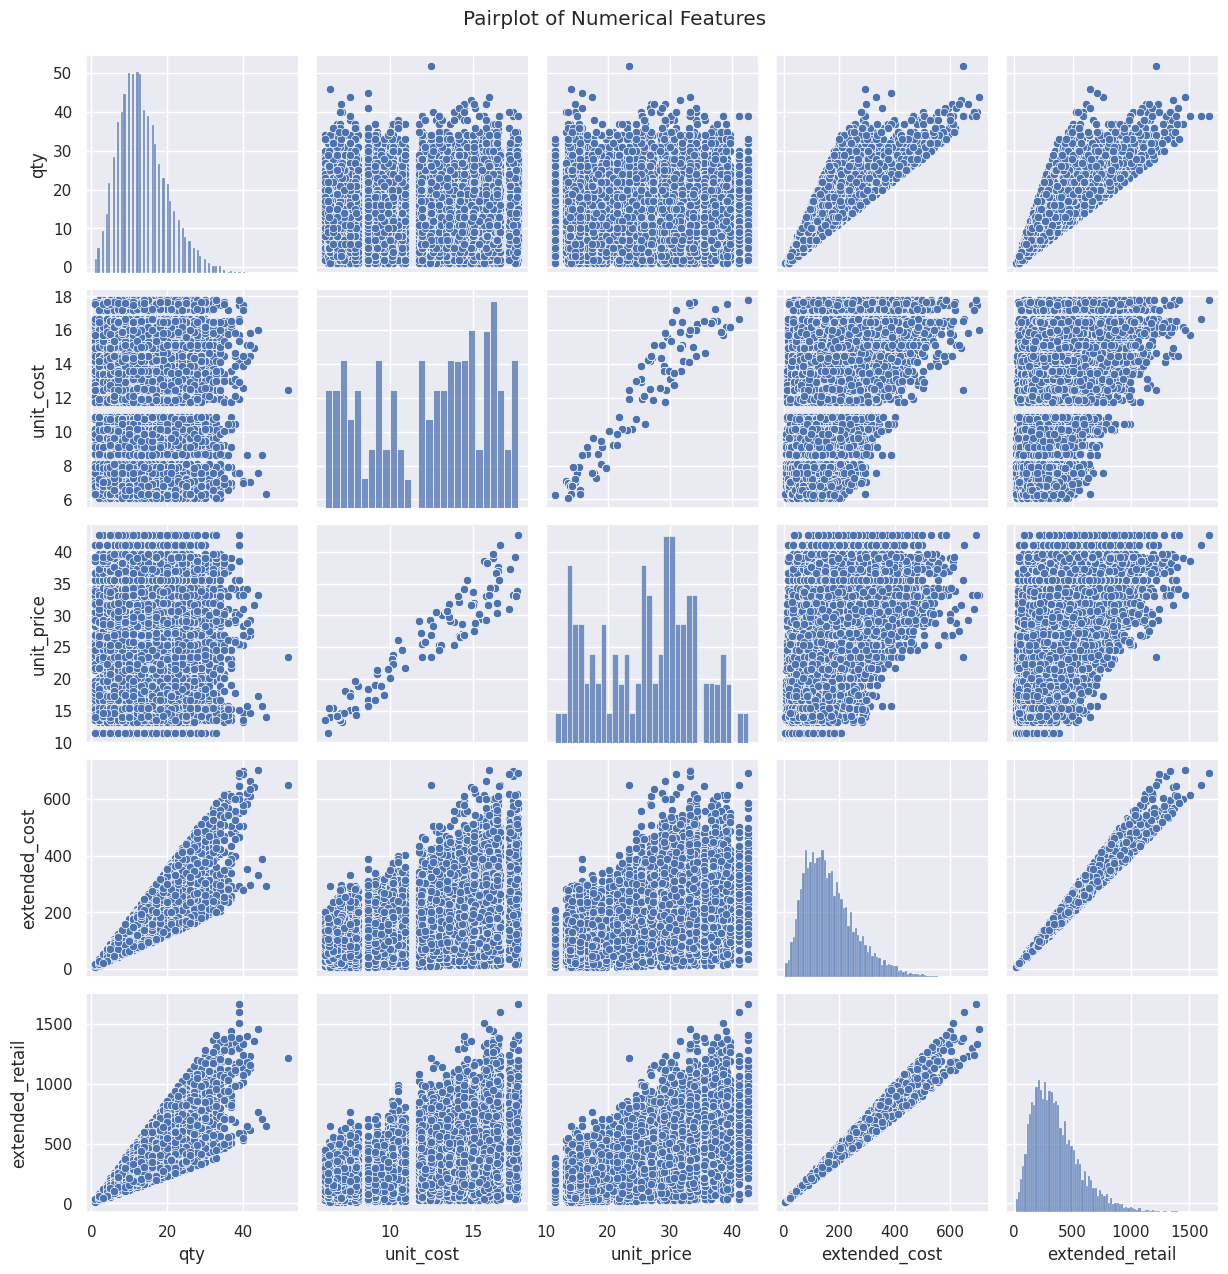

In [17]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

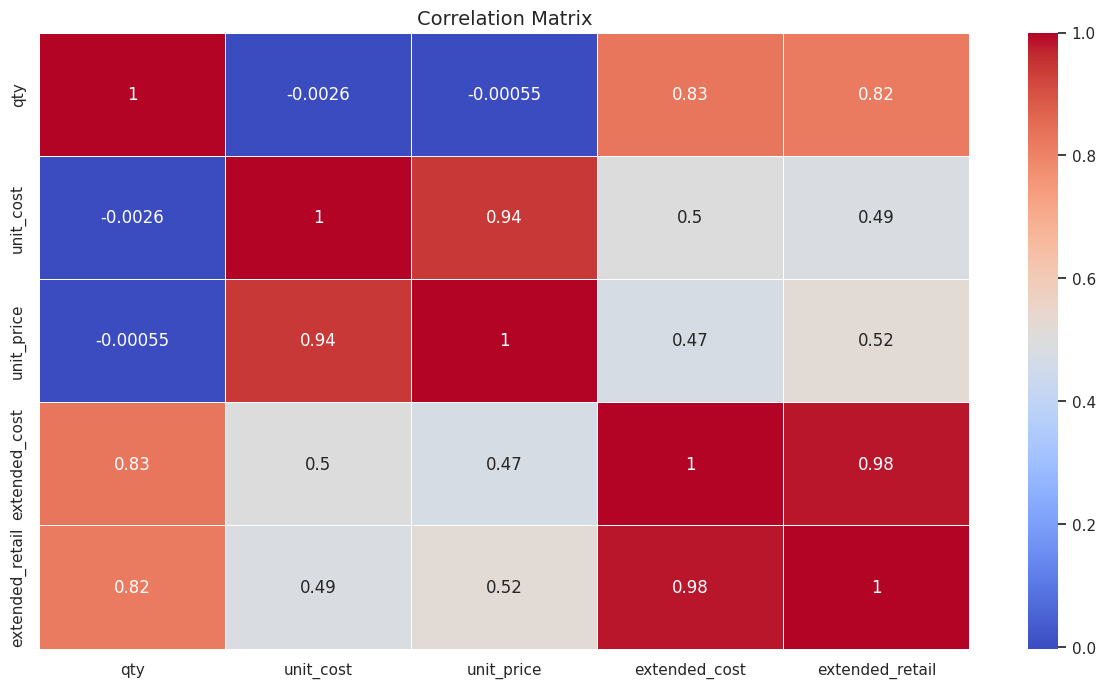

In [18]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank You